Match Land Cover Data with FVC Data

In [3]:
%pip install -q rasterio rioxarray geopandas shapely pyproj matplotlib numpy

978.25s - pydevd: Sending message related to process being replaced timed-out after 5 seconds



[notice] A new release of pip is available: 23.2.1 -> 25.0.1
[notice] To update, run: pip install --upgrade pip
Note: you may need to restart the kernel to use updated packages.


In [8]:
import rasterio
import matplotlib.pyplot as plt
import numpy as np
from pathlib import Path

clcd_path = Path('/Users/wangze/Dropbox/Emi/LandControl/geodata/CLCD_v01_2017_albert_province/CLCD_v01_2017_albert_jiangsu.tif')

In [9]:
with rasterio.open(clcd_path) as src:
    print("文件名:", src.name)
    print("投影 (CRS):", src.crs)
    print("分辨率:", src.res)
    print("尺寸:", src.width, "×", src.height)
    print("范围:", src.bounds)
    print("波段数:", src.count)
    print("数据类型:", src.dtypes[0])
    print("NoData 值:", src.nodata)

    clcd = src.read(1)

文件名: /Users/wangze/Dropbox/Emi/LandControl/geodata/CLCD_v01_2017_albert_province/CLCD_v01_2017_albert_jiangsu.tif
投影 (CRS): PROJCS["unknown",GEOGCS["WGS 84",DATUM["WGS_1984",SPHEROID["WGS 84",6378137,298.257223563,AUTHORITY["EPSG","7030"]],AUTHORITY["EPSG","6326"]],PRIMEM["Greenwich",0],UNIT["degree",0.0174532925199433,AUTHORITY["EPSG","9122"]],AUTHORITY["EPSG","4326"]],PROJECTION["Albers_Conic_Equal_Area"],PARAMETER["latitude_of_center",0],PARAMETER["longitude_of_center",105],PARAMETER["standard_parallel_1",25],PARAMETER["standard_parallel_2",47],PARAMETER["false_easting",0],PARAMETER["false_northing",0],UNIT["metre",1,AUTHORITY["EPSG","9001"]],AXIS["Easting",EAST],AXIS["Northing",NORTH]]
分辨率: (30.0, 30.0)
尺寸: 18443 × 16028
范围: BoundingBox(left=1019279.4797819705, bottom=3370781.0459234137, right=1572569.4797819704, top=3851621.0459234137)
波段数: 1
数据类型: uint8
NoData 值: 0.0


In [4]:
import numpy as np
import rasterio
from rasterio.warp import calculate_default_transform, reproject, Resampling
import glob
from pathlib import Path

# === 路径设置 ===
fvc_dir = Path("/Users/wangze/cropland_data/fvc/2017")
fvc_dev = Path("/Users/wangze/Dropbox/Emi/LandControl/geodata/Jiangsu_fvc")

# 可选：定义要处理的 tile 列表
tiles = ["N50_30", "N51_30"]

# 目标投影系 (China CGCS2000 / Gauss–Kruger Zone 19)
TARGET_CRS = "EPSG:4547"

for tile in tiles:
    print(f"\n🌍 Processing tile: {tile} ...")

    # === Step 1. 找到该 tile 的 24 期文件 ===
    files = sorted(glob.glob(str(fvc_dir / f"{tile}_FVC-2017-*-30m.tif")))
    if len(files) == 0:
        print(f"⚠️ No files found for {tile}")
        continue
    print(f"  Found {len(files)} half-monthly files.")

    # === Step 2. 打开第一个文件，建立基准 ===
    with rasterio.open(files[0]) as ref:
        ref_meta = ref.meta.copy()
        ref_shape = (ref.height, ref.width)
        ref_crs = ref.crs
        ref_transform = ref.transform

    # === Step 3. 初始化累积矩阵 ===
    mean_fvc = np.zeros(ref_shape, dtype=np.float64)
    count = np.zeros(ref_shape, dtype=np.int32)

    # === Step 4. 循环累加 ===
    for t, f in enumerate(files, 1):
        with rasterio.open(f) as src:
            arr = src.read(1).astype(np.float32)
            arr[arr > 100] = np.nan  # 无效值
            arr /= 100.0
            mask = np.isfinite(arr)
            mean_fvc[mask] += arr[mask]
            count[mask] += 1
        print(f"  ✅ processed {t:02d}/24")

    # === Step 5. 计算平均值 ===
    mean_fvc = np.divide(mean_fvc, count, out=np.zeros_like(mean_fvc), where=count > 0)
    mean_fvc = mean_fvc.astype(np.float32)

    # === Step 6. 保存为原始坐标系临时文件 ===
    temp_path = fvc_dev / f"FVC_2017_{tile}_mean_raw.tif"
    out_meta = ref_meta.copy()
    out_meta.update({
        "driver": "GTiff",
        "dtype": "float32",
        "count": 1
    })
    with rasterio.open(temp_path, "w", **out_meta) as dst:
        dst.write(mean_fvc, 1)
    print(f"  💾 Saved temporary mean file → {temp_path}")

    # === Step 7. 重投影为 EPSG:4547 ===
    reprojected_path = fvc_dev / f"FVC_2017_{tile}_mean_4547.tif"
    with rasterio.open(temp_path) as src:
        transform, width, height = calculate_default_transform(
            src.crs, TARGET_CRS, src.width, src.height, *src.bounds
        )
        kwargs = src.meta.copy()
        kwargs.update({
            "crs": TARGET_CRS,
            "transform": transform,
            "width": width,
            "height": height,
            "dtype": "float32"
        })

        with rasterio.open(reprojected_path, "w", **kwargs) as dst:
            reproject(
                source=rasterio.band(src, 1),
                destination=rasterio.band(dst, 1),
                src_transform=src.transform,
                src_crs=src.crs,
                dst_transform=transform,
                dst_crs=TARGET_CRS,
                resampling=Resampling.bilinear
            )
    print(f"  🌐 Reprojected to EPSG:4547 → {reprojected_path}")

print("\n✅ All tiles processed & reprojected successfully!")



🌍 Processing tile: N50_30 ...
  Found 24 half-monthly files.
  ✅ processed 01/24
  ✅ processed 02/24
  ✅ processed 03/24
  ✅ processed 04/24
  ✅ processed 05/24
  ✅ processed 06/24
  ✅ processed 07/24
  ✅ processed 08/24
  ✅ processed 09/24
  ✅ processed 10/24
  ✅ processed 11/24
  ✅ processed 12/24
  ✅ processed 13/24
  ✅ processed 14/24
  ✅ processed 15/24
  ✅ processed 16/24
  ✅ processed 17/24
  ✅ processed 18/24
  ✅ processed 19/24
  ✅ processed 20/24
  ✅ processed 21/24
  ✅ processed 22/24
  ✅ processed 23/24
  ✅ processed 24/24
  💾 Saved temporary mean file → /Users/wangze/Dropbox/Emi/LandControl/geodata/Jiangsu_fvc/FVC_2017_N50_30_mean_raw.tif
  🌐 Reprojected to EPSG:4547 → /Users/wangze/Dropbox/Emi/LandControl/geodata/Jiangsu_fvc/FVC_2017_N50_30_mean_4547.tif

🌍 Processing tile: N51_30 ...
  Found 24 half-monthly files.
  ✅ processed 01/24
  ✅ processed 02/24
  ✅ processed 03/24
  ✅ processed 04/24
  ✅ processed 05/24
  ✅ processed 06/24
  ✅ processed 07/24
  ✅ processed 08/2

✅ 读取成功!
CRS: EPSG:4547
分辨率: (30.032672113451262, 30.032672113451262)
范围: BoundingBox(left=678838.6831488275, bottom=3411242.8532882654, right=1286760.032069308, top=3934231.8054719055)
最小值: 0 最大值: 8

土地类型类别 (前20个):
  类别值=  1，像元数=78595647
  类别值=  2，像元数=1878580
  类别值=  4，像元数=6252
  类别值=  5，像元数=13585627
  类别值=  7，像元数=1552
  类别值=  8，像元数=19752288


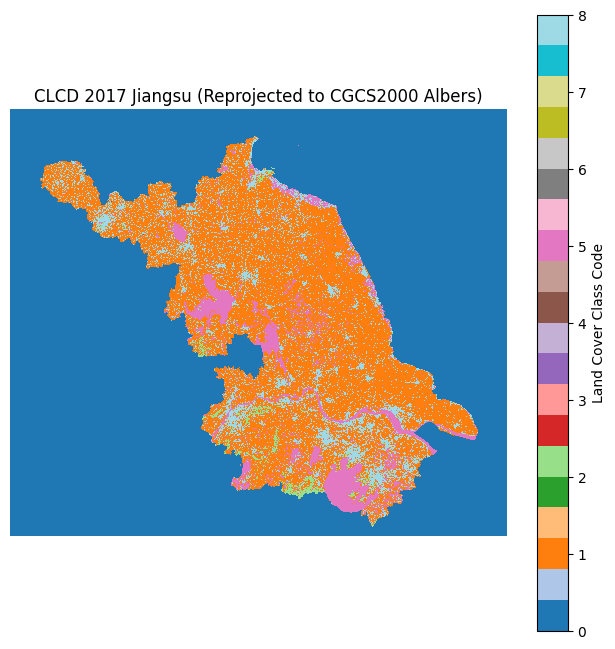

In [13]:
import rasterio
import matplotlib.pyplot as plt
import numpy as np

# === 1. 文件路径 ===
clcd_albers_path = "/Users/wangze/Dropbox/Emi/LandControl/geodata/Jiangsu_CGCS2000/CLCD_v01_2017_albert_jiangsu_albers.tif"

# === 2. 读取栅格 ===
with rasterio.open(clcd_albers_path) as src:
    clcd_albers = src.read(1)
    crs = src.crs
    bounds = src.bounds
    res = src.res

print("✅ 读取成功!")
print("CRS:", crs)
print("分辨率:", res)
print("范围:", bounds)
print("最小值:", np.nanmin(clcd_albers), "最大值:", np.nanmax(clcd_albers))

# === 3. 统计分类值分布 ===
vals, counts = np.unique(clcd_albers[clcd_albers > 0], return_counts=True)
print("\n土地类型类别 (前20个):")
for v, c in list(zip(vals, counts))[:20]:
    print(f"  类别值={int(v):>3}，像元数={c}")

# === 4. 可视化（使用分类色表）===
plt.figure(figsize=(8,8))
plt.imshow(clcd_albers, cmap="tab20", interpolation="nearest")
plt.title("CLCD 2017 Jiangsu (Reprojected to CGCS2000 Albers)", fontsize=12)
plt.colorbar(label="Land Cover Class Code")
plt.axis("off")
plt.show()


✅ 重叠区域: 1305540.0, 3244770.0, 1460190.0, 3875040.0
📊 RMSE: 0.0032
📊 平均差值 (N50 - N51): 0.0009
📊 有效像元数: 108,301,395


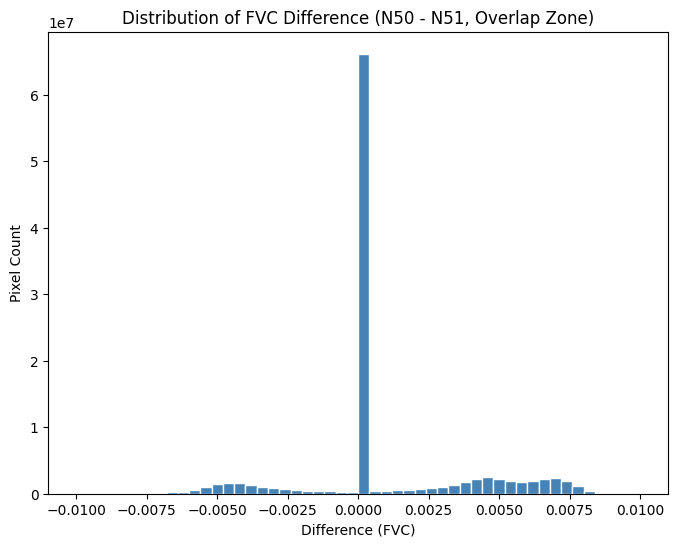

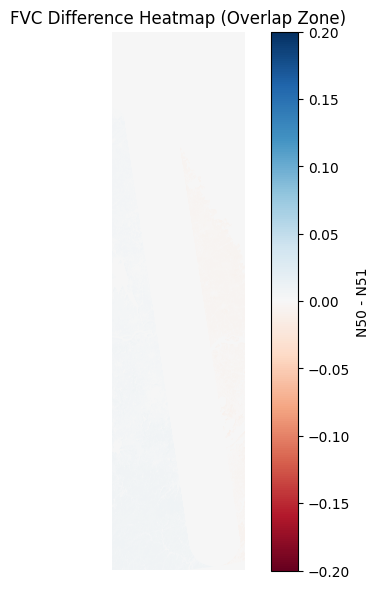

In [ ]:
import rasterio
from rasterio.warp import reproject, Resampling
from rasterio.windows import from_bounds
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path

# === 1. 文件路径 ===
base_dir = Path("/Users/wangze/Dropbox/Emi/LandControl/geodata/Jiangsu_fvc")
fvc_n50_path = base_dir / "FVC_2017_N50_30_mean.tif"
fvc_n51_path = base_dir / "FVC_2017_N51_30_mean.tif"

# === 2. 读取元数据 ===
with rasterio.open(fvc_n50_path) as src50, rasterio.open(fvc_n51_path) as src51:
    bounds50, bounds51 = src50.bounds, src51.bounds
    overlap_left = max(bounds50.left, bounds51.left)
    overlap_right = min(bounds50.right, bounds51.right)
    overlap_bottom = max(bounds50.bottom, bounds51.bottom)
    overlap_top = min(bounds50.top, bounds51.top)
    print(f"✅ 重叠区域: {overlap_left:.1f}, {overlap_bottom:.1f}, {overlap_right:.1f}, {overlap_top:.1f}")

    # === 3. 裁剪重叠区域 ===
    win50 = from_bounds(overlap_left, overlap_bottom, overlap_right, overlap_top, src50.transform)
    win51 = from_bounds(overlap_left, overlap_bottom, overlap_right, overlap_top, src51.transform)
    arr50 = src50.read(1, window=win50).astype(np.float32) / 100.0
    arr51 = src51.read(1, window=win51).astype(np.float32) / 100.0

    # === 4. 对齐 N51 到 N50 网格 ===
    aligned51 = np.empty_like(arr50)
    reproject(
        source=arr51,
        destination=aligned51,
        src_transform=src51.window_transform(win51),
        src_crs=src51.crs,
        dst_transform=src50.window_transform(win50),
        dst_crs=src50.crs,
        resampling=Resampling.bilinear,
    )

# === 5. 差异分析 ===
mask = np.isfinite(arr50) & np.isfinite(aligned51)
diff = arr50[mask] - aligned51[mask]
rmse = np.sqrt(np.nanmean(diff**2))
mean_diff = np.nanmean(diff)

print(f"📊 RMSE: {rmse:.4f}")
print(f"📊 平均差值 (N50 - N51): {mean_diff:.4f}")
print(f"📊 有效像元数: {mask.sum():,}")

# === 6. 可视化差异 ===
plt.figure(figsize=(8,6))
plt.hist(diff, bins=50, color="steelblue", edgecolor="white")
plt.title("Distribution of FVC Difference (N50 - N51, Overlap Zone)")
plt.xlabel("Difference (FVC)")
plt.ylabel("Pixel Count")
plt.show()

plt.figure(figsize=(7,7))
plt.imshow(diff.reshape(arr50.shape), cmap="RdBu", vmin=-0.2, vmax=0.2)
plt.colorbar(label="N50 - N51")
plt.title("FVC Difference Heatmap (Overlap Zone)")
plt.axis("off")
plt.show()
——




In [4]:
import numpy as np
import rasterio
from rasterio.merge import merge
from rasterio.mask import mask
from rasterio.warp import reproject, Resampling
from shapely.geometry import box
import matplotlib.pyplot as plt
from pathlib import Path

# === 路径 ===
base_dir = Path("/Users/wangze/Dropbox/Emi/LandControl/geodata")
fvc50_path = base_dir / "Jiangsu_fvc/FVC_2017_N50_30_mean_4547.tif"
fvc51_path = base_dir / "Jiangsu_fvc/FVC_2017_N51_30_mean_4547.tif"
clcd_path = base_dir / "Jiangsu_CGCS2000/CLCD_v01_2017_albert_jiangsu_albers.tif"

# === Step 1. 读取 FVC ===
with rasterio.open(fvc50_path) as src50, rasterio.open(fvc51_path) as src51:
    meta_ref = src50.meta.copy()

    # === 先读取数据 ===
    arr50 = src50.read(1).astype(np.float32)
    arr51 = src51.read(1).astype(np.float32)

    # === 将异常值设为 NaN ===
    arr50[(arr50 <= 0) | (arr50 > 1)] = np.nan
    arr51[(arr51 <= 0) | (arr51 > 1)] = np.nan

    # === Step 1.5. 将 N51 重投影到 N50 的格网 ===
    aligned51 = np.empty_like(arr50, dtype=np.float32)
    reproject(
        source=arr51,
        destination=aligned51,
        src_transform=src51.transform,
        src_crs=src51.crs,
        dst_transform=src50.transform,
        dst_crs=src50.crs,
        resampling=Resampling.bilinear
    )


# === Step 2. 更健壮的合并逻辑 ===
aligned51[(aligned51 <= 0) | (aligned51 > 1)] = np.nan
mask_50 = np.isfinite(arr50)
mask_51 = np.isfinite(aligned51)
mask_both = mask_50 & mask_51

merged_fvc = np.full_like(arr50, np.nan, dtype=np.float32)
merged_fvc[mask_both] = arr50[mask_both]  # 若两者都有值，暂取 N50（或可改为平均）

# 若仅一方有值 → 取该方
mask_only_50 = mask_50 & ~mask_51
mask_only_51 = ~mask_50 & mask_51
merged_fvc[mask_only_50] = arr50[mask_only_50]
merged_fvc[mask_only_51] = aligned51[mask_only_51]

# 若都为 NaN → 保持 NaN
print("🧩 合并完成（完全格网对齐）")



🧩 合并完成（完全格网对齐）


In [5]:
import rasterio
from rasterio.merge import merge
from rasterio.enums import Resampling
from pathlib import Path

base_dir = Path("/Users/wangze/Dropbox/Emi/LandControl/geodata")
fvc50_path = base_dir / "Jiangsu_fvc/FVC_2017_N50_30_mean_4547.tif"
fvc51_path = base_dir / "Jiangsu_fvc/FVC_2017_N51_30_mean_4547.tif"

# 打开两个文件
srcs = [rasterio.open(fvc50_path), rasterio.open(fvc51_path)]

# 手动计算并扩大 bounds
all_bounds = [s.bounds for s in srcs]
minx = min(b.left for b in all_bounds)
maxx = max(b.right for b in all_bounds)
miny = min(b.bottom for b in all_bounds)
maxy = max(b.top for b in all_bounds)
full_bounds = (minx, miny, maxx, maxy)

# 拼接（保留全部范围）
mosaic, out_trans = merge(
    srcs,
    bounds=full_bounds,
    res=srcs[0].res,  # 保持相同分辨率
    method="max",     # 优先保留较大像元（即非空值）
    precision=1       # 允许轻微格网容差
)

# 保存
out_meta = srcs[0].meta.copy()
out_meta.update({
    "driver": "GTiff",
    "height": mosaic.shape[1],
    "width": mosaic.shape[2],
    "transform": out_trans,
    "crs": "EPSG:4547",
    "dtype": "float32",
    "count": 1
})

out_path = base_dir / "Jiangsu_fvc/FVC_2017_Jiangsu_merged_full_4547.tif"
with rasterio.open(out_path, "w", **out_meta) as dst:
    dst.write(mosaic[0], 1)

print(f"✅ Saved full merged map → {out_path}")


/Users/wangze/Dropbox/Emi/LandControl/.venv/lib/python3.12/site-packages/rasterio/merge.py:217: RasterioDeprecationWarning: The precision parameter is unused, deprecated, and will be removed in 2.0.0.
  warnings.warn(


✅ Saved full merged map → /Users/wangze/Dropbox/Emi/LandControl/geodata/Jiangsu_fvc/FVC_2017_Jiangsu_merged_full_4547.tif


In [2]:
# ===== Jiangsu cropland fallow mapping (CLCD × merged FVC) =====
import numpy as np
import rasterio
from rasterio.warp import reproject, Resampling
import matplotlib.pyplot as plt
from pathlib import Path

# ---------- paths ----------
base = Path("/Users/wangze/Dropbox/Emi/LandControl/geodata")
clcd_path  = base / "Jiangsu_CGCS2000/CLCD_v01_2017_albert_jiangsu_albers.tif"
fvc_path   = base / "Jiangsu_fvc/FVC_2017_Jiangsu_merged_full_4547.tif"  # 上一步合并好的那个
out_dir    = base / "Jiangsu_fvc"
out_dir.mkdir(parents=True, exist_ok=True)

# ---------- params ----------
CROPLAND_CODES = {1}        # 你已确认 CLCD 耕地=1；如有子类可写成 {11,12}
FALLOW_THR = 0.30           # FVC 低于此阈值视为撂荒（可改成 0.25 或 0.35 做敏感性分析）
FALLOW_NODATA = 255         # 输出栅格 nodata

# ---------- read rasters ----------
with rasterio.open(clcd_path) as clcd_src:
    clcd = clcd_src.read(1)
    clcd_meta = clcd_src.meta.copy()
    clcd_crs  = clcd_src.crs
    clcd_tf   = clcd_src.transform
    clcd_shape = (clcd_src.height, clcd_src.width)

with rasterio.open(fvc_path) as fvc_src:
    fvc = fvc_src.read(1).astype(np.float32)
    fvc_crs = fvc_src.crs
    fvc_tf  = fvc_src.transform

print("CRS:", "\n  CLCD:", clcd_crs, "\n  FVC :", fvc_crs)

# ---------- align FVC to CLCD grid (only if needed) ----------
if fvc_crs != clcd_crs or fvc.shape != clcd_shape or fvc_tf != clcd_tf:
    aligned_fvc = np.full(clcd_shape, np.nan, dtype=np.float32)
    reproject(
        source=fvc,
        destination=aligned_fvc,
        src_transform=fvc_tf,
        src_crs=fvc_crs,
        dst_transform=clcd_tf,
        dst_crs=clcd_crs,
        resampling=Resampling.bilinear,
        src_nodata=None,
        dst_nodata=np.nan,
    )
    fvc = aligned_fvc
    print("✅ FVC 已对齐到 CLCD 网格。")
else:
    print("✅ FVC 与 CLCD 天然对齐。")

# ---------- sanitize FVC ----------
# 有些工具写出的 FVC 可能有轻微越界或 0/负值；统一限定在 [0,1]，其余设为 NaN
fvc = fvc.astype(np.float32)
fvc[~np.isfinite(fvc)] = np.nan
fvc[(fvc < 0) | (fvc > 1)] = np.nan

# ---------- cropland mask ----------
if len(CROPLAND_CODES) == 1:
    cropland_mask = (clcd == next(iter(CROPLAND_CODES)))
else:
    # 多码写法：如 {11,12}
    cropland_mask = np.isin(clcd, list(CROPLAND_CODES))

valid_on_cropland = cropland_mask & np.isfinite(fvc)

# ---------- fallow map (0/1 with nodata) ----------
fallow_bool = np.zeros_like(fvc, dtype=bool)
fallow_bool[valid_on_cropland] = (fvc[valid_on_cropland] < FALLOW_THR)

fallow_u8 = np.full(fvc.shape, FALLOW_NODATA, dtype=np.uint8)  # 255=nodata
fallow_u8[valid_on_cropland] = fallow_bool[valid_on_cropland].astype(np.uint8)

# ---------- stats ----------
total_cropland = int(cropland_mask.sum())
valid_cropland = int(valid_on_cropland.sum())
fallow_pixels  = int(fallow_bool.sum())
fallow_rate    = (fallow_pixels / valid_cropland) if valid_cropland > 0 else np.nan

print("\n📊 撂荒统计（基于 FVC < {:.2f}）：".format(FALLOW_THR))
print("  耕地像元总数：{:,.0f}".format(total_cropland))
print("  有效FVC耕地像元：{:,.0f}".format(valid_cropland))
print("  撂荒像元数：{:,.0f}".format(fallow_pixels))
print("  撂荒率：{:.2%}".format(fallow_rate))

# === 生成耕地区域内的 FVC 连续图 ===
fvc_cropland = np.full_like(fvc, np.nan, dtype=np.float32)
fvc_cropland[valid_on_cropland] = fvc[valid_on_cropland]

out_fvc_tif = out_dir / "FVC_Jiangsu_2017_cropland_only_4547.tif"

fvc_meta = clcd_meta.copy()
fvc_meta.update({
    "driver": "GTiff",
    "dtype": "float32",
    "count": 1,
    "nodata": np.nan
})

with rasterio.open(out_fvc_tif, "w", **fvc_meta) as dst:
    dst.write(fvc_cropland, 1)

print(f"✅ 连续型 FVC（仅耕地）已保存至: {out_fvc_tif}")


CRS: 
  CLCD: EPSG:4547 
  FVC : EPSG:4547
✅ FVC 已对齐到 CLCD 网格。

📊 撂荒统计（基于 FVC < 0.30）：
  耕地像元总数：78,595,647
  有效FVC耕地像元：78,595,647
  撂荒像元数：12,480,600
  撂荒率：15.88%
✅ 连续型 FVC（仅耕地）已保存至: /Users/wangze/Dropbox/Emi/LandControl/geodata/Jiangsu_fvc/FVC_Jiangsu_2017_cropland_only_4547.tif


📊 江苏耕地FVC统计 (2017)
  样本数量: 78,595,647
  平均值: 0.413
  中位数: 0.436
  标准差: 0.141
  25%-75% 四分位区间: [0.353, 0.501]


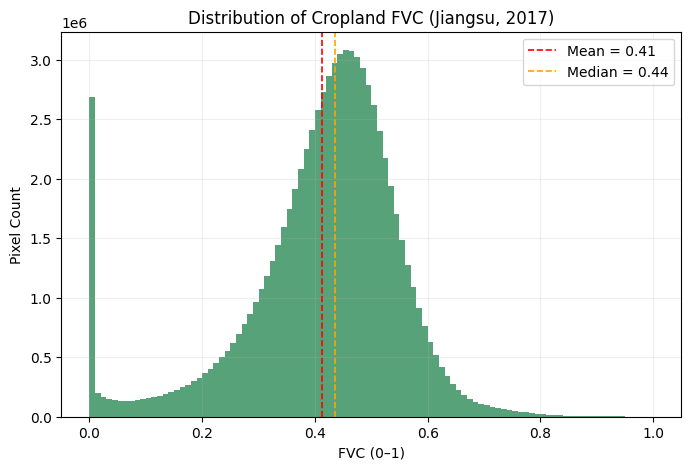

In [3]:
import numpy as np
import rasterio
import matplotlib.pyplot as plt
from pathlib import Path

# === 路径设置 ===
base_dir = Path("/Users/wangze/Dropbox/Emi/LandControl/geodata/Jiangsu_fvc")
fvc_cropland_path = base_dir / "FVC_Jiangsu_2017_cropland_only_4547.tif"

# === 读取数据 ===
with rasterio.open(fvc_cropland_path) as src:
    fvc_data = src.read(1).astype(np.float32)

# === 去除 NaN ===
fvc_valid = fvc_data[np.isfinite(fvc_data)]

# === 基本统计量 ===
mean_fvc = np.nanmean(fvc_valid)
median_fvc = np.nanmedian(fvc_valid)
std_fvc = np.nanstd(fvc_valid)
q25, q75 = np.nanpercentile(fvc_valid, [25, 75])

print(f"📊 江苏耕地FVC统计 (2017)")
print(f"  样本数量: {len(fvc_valid):,}")
print(f"  平均值: {mean_fvc:.3f}")
print(f"  中位数: {median_fvc:.3f}")
print(f"  标准差: {std_fvc:.3f}")
print(f"  25%-75% 四分位区间: [{q25:.3f}, {q75:.3f}]")

# === 绘制直方图 ===
plt.figure(figsize=(8,5))
plt.hist(fvc_valid, bins=100, range=(0,1), color='seagreen', alpha=0.8, edgecolor='none')

plt.axvline(mean_fvc, color='red', linestyle='--', linewidth=1.2, label=f"Mean = {mean_fvc:.2f}")
plt.axvline(median_fvc, color='orange', linestyle='--', linewidth=1.2, label=f"Median = {median_fvc:.2f}")

plt.title("Distribution of Cropland FVC (Jiangsu, 2017)")
plt.xlabel("FVC (0–1)")
plt.ylabel("Pixel Count")
plt.legend()
plt.grid(alpha=0.2)
plt.show()
